<a href="https://colab.research.google.com/github/godlikeanyone/HDAT-9000-2026T2/blob/main/HDAT_9000_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://github.com/godlikeanyone/HDAT-9000-2026T2/raw/refs/heads/main/pred.csv

--2026-06-21 08:12:44--  https://github.com/godlikeanyone/HDAT-9000-2026T2/raw/refs/heads/main/pred.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/godlikeanyone/HDAT-9000-2026T2/refs/heads/main/pred.csv [following]
--2026-06-21 08:12:44--  https://raw.githubusercontent.com/godlikeanyone/HDAT-9000-2026T2/refs/heads/main/pred.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19900749 (19M) [text/plain]
Saving to: ‘pred.csv’

pred.csv            100%[===================>]  18.98M  --.-KB/s    in 0.1s    

2026-06-21 08:12:45 (160 MB/s) - ‘pred.csv’ saved [19900749/19900749]



# Q1
## 1.a

In [2]:
import pandas as pd
import numpy as np

# Load CSV
try:
  df = pd.read_csv('pred.csv')
except FileNotFoundError:
  print("File Not Found.")
  exit()

# Extract the true labels 'y' and all probability columns
y_true = df['y']
probs = df.loc[:, 'prob_1':'prob_500']

mean_probs = probs.mean(axis=1)
bias_error = np.mean((y_true - mean_probs) ** 2)
variance_error = np.mean(probs.var(axis=1, ddof=1))

print(f"Expected Bias Error: {bias_error:.2f}")
print(f"Expected Variance Error: {variance_error:.2f}")

Expected Bias Error: 0.07
Expected Variance Error: 0.03


## 1.b
The estimated Expected Bias Error (0.07) and Expected Variance Error (0.03) are both relatively low. This implies that the model is highly stable across different bootstrap samples (low variance) and accurately captures the underlying patterns of STEMI without severe systematic errors (low bias). Given the critical nature of STEMI diagnosis, the low variance is particularly reassuring, as it means the model's predictions are reliable and consistent. Therefore, the model is highly suitable as a robust clinical decision support tool.

## 1.c
Since the hypothetical model achieves the same expected error, the magnitude of the total error is 0.10. The total error is the sum of expected bias error, expected variance error, and irreducible error. Since the hypothetical model is a perfect model, it has 0 expected variance error and 0 bias error. The magnitude of total error fully depends on the irruducible error.

This error could be caused by noise or missing features. In STEMI diagnosis, an ECG alone does not contain 100% of the information required for a definitive diagnosis. Other critical variables, such as blood biomarker levels or patient clinical history, are not available to the model. Also, there could be sensor noise.

# Q2
## 2.a

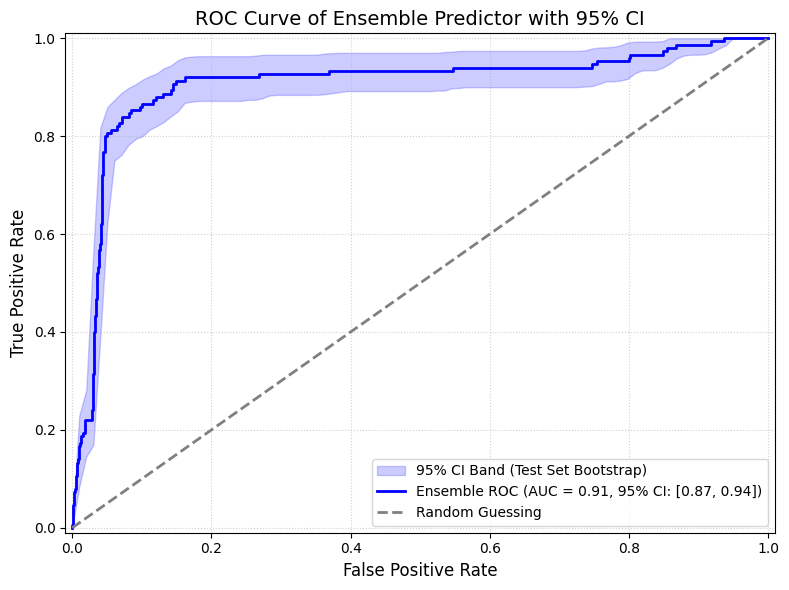

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample

ensemble_probs = np.mean(probs, axis=1)

main_fpr, main_tpr, _ = roc_curve(y_true, ensemble_probs)
main_auc = auc(main_fpr, main_tpr)

n_bootstraps = 500
boot_aucs = []
base_fpr = np.linspace(0, 1, 100)
tprs_interpolated = []

np.random.seed(42)

for i in range(n_bootstraps):
    indices = resample(np.arange(len(y_true)), replace=True)
    y_boot = y_true[indices]
    probs_boot = ensemble_probs[indices]

    if len(np.unique(y_boot)) < 2:
        continue

    fpr_i, tpr_i, _ = roc_curve(y_boot, probs_boot)
    boot_aucs.append(auc(fpr_i, tpr_i))

    tpr_interp = np.interp(base_fpr, fpr_i, tpr_i)
    tpr_interp[0] = 0.0
    tprs_interpolated.append(tpr_interp)

auc_lower = np.percentile(boot_aucs, 2.5)
auc_upper = np.percentile(boot_aucs, 97.5)

tprs_matrix = np.array(tprs_interpolated)
tpr_lower = np.percentile(tprs_matrix, 2.5, axis=0)
tpr_upper = np.percentile(tprs_matrix, 97.5, axis=0)
tpr_upper[-1] = 1.0

plt.figure(figsize=(8, 6))
plt.fill_between(base_fpr, tpr_lower, tpr_upper, color='blue', alpha=0.2,
                 label='95% CI Band (Test Set Bootstrap)')


plt.plot(main_fpr, main_tpr, color='blue', lw=2,
         label=f'Ensemble ROC (AUC = {main_auc:.2f}, 95% CI: [{auc_lower:.2f}, {auc_upper:.2f}])')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guessing')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve of Ensemble Predictor with 95% CI', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 2.b

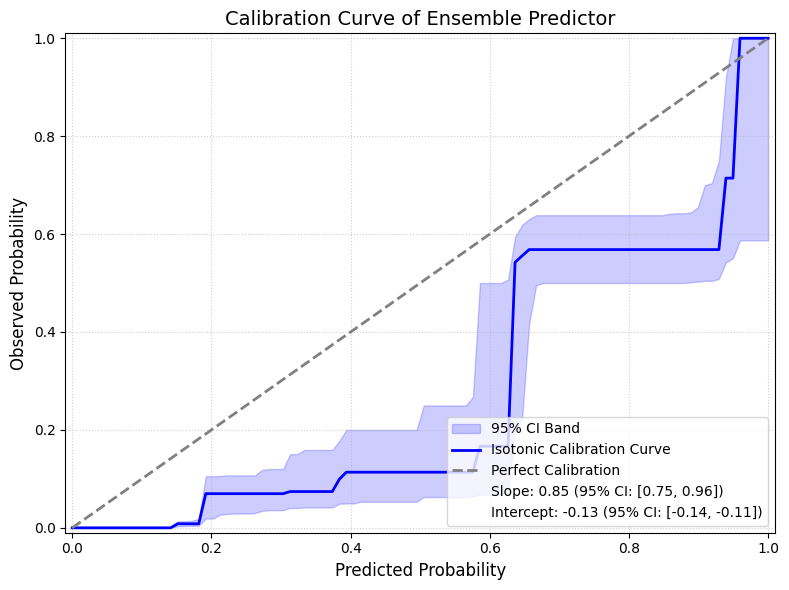

In [8]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression

p_grid = np.linspace(0, 1, 100)

ir_main = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
ir_main.fit(ensemble_probs, y_true)
calib_main = ir_main.predict(p_grid)

lr_main = LinearRegression()
lr_main.fit(ensemble_probs.reshape(-1, 1), y_true)
slope_main = lr_main.coef_[0]
intercept_main = lr_main.intercept_

n_bootstraps = 500
boot_curves = []
boot_slopes = []
boot_intercepts = []

np.random.seed(42)

for i in range(n_bootstraps):
    indices = resample(np.arange(len(y_true)), replace=True)
    y_boot = y_true[indices]
    p_boot = ensemble_probs[indices]

    if len(np.unique(y_boot)) < 2:
        continue

    ir = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    ir.fit(p_boot, y_boot)
    boot_curves.append(ir.predict(p_grid))

    lr = LinearRegression()
    lr.fit(p_boot.reshape(-1, 1), y_boot)
    boot_slopes.append(lr.coef_[0])
    boot_intercepts.append(lr.intercept_)

curves_matrix = np.array(boot_curves)
curve_lower = np.percentile(curves_matrix, 2.5, axis=0)
curve_upper = np.percentile(curves_matrix, 97.5, axis=0)

slope_lower = np.percentile(boot_slopes, 2.5)
slope_upper = np.percentile(boot_slopes, 97.5)

intercept_lower = np.percentile(boot_intercepts, 2.5)
intercept_upper = np.percentile(boot_intercepts, 97.5)

plt.figure(figsize=(8, 6))

plt.fill_between(p_grid, curve_lower, curve_upper, color='blue', alpha=0.2,
                 label='95% CI Band')

plt.plot(p_grid, calib_main, color='blue', lw=2,
         label='Isotonic Calibration Curve')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Perfect Calibration')

slope_text = f"Slope: {slope_main:.2f} (95% CI: [{slope_lower:.2f}, {slope_upper:.2f}])"
intercept_text = f"Intercept: {intercept_main:.2f} (95% CI: [{intercept_lower:.2f}, {intercept_upper:.2f}])"

plt.plot([], [], ' ', label=slope_text)
plt.plot([], [], ' ', label=intercept_text)

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Observed Probability', fontsize=12)
plt.title('Calibration Curve of Ensemble Predictor', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 2.c
The performance of discrimination is excellent, but the calibration is poor. It successfully distinguishes between STEMI and non-STEMI cases, meaning high-risk patients are consistently assigned higher scores than low-risk patients. However, the calibration curve reveals a severe systematic overestimation of STEMI risk. The curve lies significantly below the ideal line.

In conclusion, this model would be a helpful screening tool in an emergency room just to flag high-risk patients quickly. However, because it is so aggressive with its scoring, doctors definitely cannot trust the raw percentage outputs. The model would need to be recalibrated before anyone could actually use its probability numbers in real life.

# Q3
## 3.1